# Install and Import Dependencies

In [18]:
!pip install tensorflow tensorflow-io librosa kagglehub -q

import kagglehub
import tensorflow as tf
import numpy as np
import librosa
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


# Download Dataset

In [19]:
dataset_path = kagglehub.dataset_download(
    "kenjee/z-by-hp-unlocked-challenge-3-signal-processing"
)

CAPUCHIN_PATH = os.path.join(dataset_path, "Parsed_Capuchinbird_Clips")
NOT_PATH = os.path.join(dataset_path, "Parsed_Not_Capuchinbird_Clips")


Using Colab cache for faster access to the 'z-by-hp-unlocked-challenge-3-signal-processing' dataset.


# Audio Settings

In [20]:
SAMPLE_RATE = 16000
DURATION = 3
SAMPLES_PER_CLIP = SAMPLE_RATE * DURATION

# Load Audio

In [21]:
def load_audio(file_path):
    audio, _ = librosa.load(file_path, sr=SAMPLE_RATE)

    if len(audio) < SAMPLES_PER_CLIP:
        audio = np.pad(audio, (0, SAMPLES_PER_CLIP - len(audio)))
    else:
        audio = audio[:SAMPLES_PER_CLIP]

    return audio

# Feature Extraction (frequency, time)

In [22]:
def extract_log_mel(audio):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SAMPLE_RATE,
        n_mels=128,
        n_fft=1024,
        hop_length=512
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel

def normalize(spec):
    return (spec - np.mean(spec)) / (np.std(spec) + 1e-6)


**Plot spectograms**

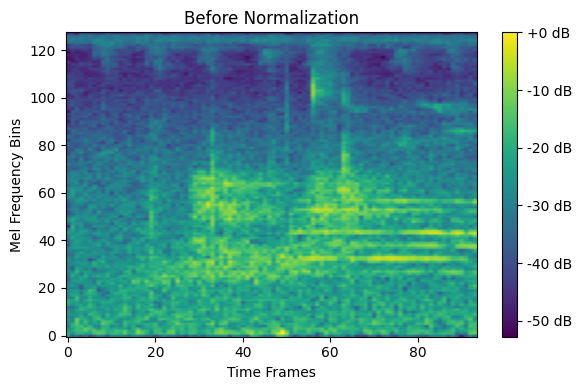

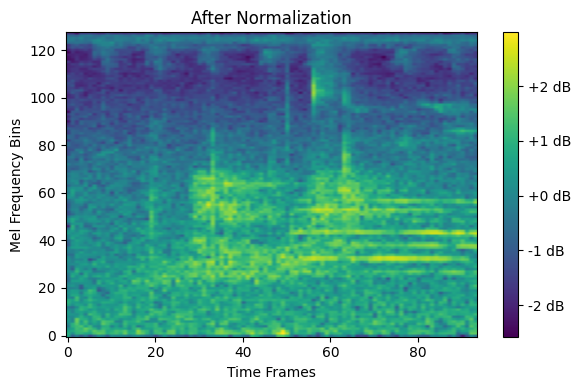

In [29]:
import matplotlib.pyplot as plt

def plot_log_mel(spec, title="Log-Mel Spectrogram"):
    plt.figure(figsize=(6, 4))
    plt.imshow(spec, aspect='auto', origin='lower')
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")
    plt.tight_layout()
    plt.show()

sample_file = os.listdir(CAPUCHIN_PATH)[0]
sample_path = os.path.join(CAPUCHIN_PATH, sample_file)

audio = load_audio(sample_path)

# Before normalization
log_mel = extract_log_mel(audio)
plot_log_mel(log_mel, title="Before Normalization")

# After normalization
norm_spec = normalize(log_mel)
plot_log_mel(norm_spec, title="After Normalization")

# Load Dataset

In [23]:
def load_dataset():
    X, y = [], []

    # Capuchin = 1
    for file in os.listdir(CAPUCHIN_PATH):
        file_path = os.path.join(CAPUCHIN_PATH, file)

        audio = load_audio(file_path)
        spec = extract_log_mel(audio)
        spec = normalize(spec)
        spec = spec[..., np.newaxis]

        X.append(spec)
        y.append(1)

    # Not Capuchin = 0
    for file in os.listdir(NOT_PATH):
        file_path = os.path.join(NOT_PATH, file)

        audio = load_audio(file_path)
        spec = extract_log_mel(audio)
        spec = normalize(spec)
        spec = spec[..., np.newaxis]

        X.append(spec)
        y.append(0)

    return np.array(X), np.array(y)

# Load and Split data into train and test sets

In [24]:
X, y = load_dataset()

print("Dataset shape:", X.shape)

indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# Resize spectrograms for CNN
X = tf.image.resize(X, (128, 128)).numpy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


Dataset shape: (810, 128, 94, 1)


# Define CNN

In [25]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 1)),

        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()


# Train model

In [26]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9383 - loss: 0.5125 - val_accuracy: 0.9008 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9965 - loss: 0.0802 - val_accuracy: 0.7851 - val_loss: 1.7096 - learning_rate: 0.0010
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9912 - loss: 0.1196 - val_accuracy: 0.7025 - val_loss: 1.3764 - learning_rate: 0.0010
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9824 - loss: 0.2290 - val_accuracy: 0.6860 - val_loss: 2.9777 - learning_rate: 0.0010
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9947 - loss: 0.0376 - val_accuracy: 0.6777 - val_loss: 2.9975 - learning_rate: 3.0000e-04
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9982 - loss: 0.0157 - val_accuracy: 0.6860 - val_loss: 2.3222 - learning_rate: 3.0000e-04


# Evaluate Model

In [28]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)


# accuracy score
accuracy = np.mean(y_pred.flatten() == y_test)
print("\nTest Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step

Test Accuracy: 0.860655737704918
